# K-Nearest Neighbors (KNN)
#### Is a non-parametric algorithm user for classification or regression problems. It classifies input data based on the majority class of k-nearest points in the feature space. Useful for small datasets where relationships among data can be easily visualized and highlighted.

## Model
#### This model does not learn anything but simply memorizes all training points.
#### For new input:
#### 1. Calculate distance to all training points (usually Euclidean):

$$
d(x,x')=\sqrt{\sum_{j=1}^{n}(x_j-x_j')^2}
$$
#### Where:
#### $x$ - training feature
#### $x'$ - input data

#### 2. Finds k-nearest neighbors.
#### 3. if it's $\textbf{classification}$ problem, it assigns input data to the majority class of k-nearest neighbors. If it's $\textbf{regression}$ problem, it assigns to input data the mean of k-nearest neighbors values.

#### It works good only for small amount of data (because it calculates distances to all training data) and small amount of features. Very vulnerable to data scaling and its normalization is often needed.

## Dataset

#### Student study hours from Kaggle has been used as a dataset. It has a correlation between study hours and scores gained on exam. Student usually passes the exam when he/she has at least 51 points, so data is being tuned in this notebook to pass/fail data for k-nearest neighbors algorithm to handle.

#### https://www.kaggle.com/datasets/himanshunakrani/student-study-hours

## 1. Import necessary libraries

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 2. Load and visualize dataset

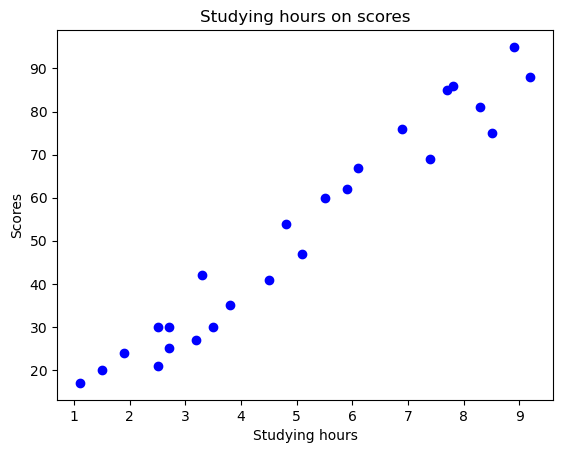

In [33]:
df = pd.read_csv('data/score.csv')
plt.scatter(df['Hours'], df['Scores'], color='blue')
plt.title('Studying hours on scores')
plt.xlabel('Studying hours')
plt.ylabel('Scores')
plt.show()

## 3. Split the data into training and testing sets and visualize exam results

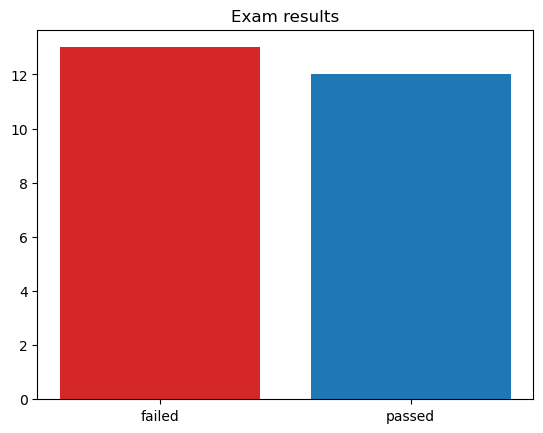

In [34]:
X = df['Hours'].to_numpy().reshape(-1, 1)
y = df['Scores'].apply(lambda x: 1 if x > 50 else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = ['failed', 'passed']
counts = [y.value_counts()[0], y.value_counts()[1]]
bar_colors = ['tab:red', 'tab:blue']

plt.bar(results, counts, color=bar_colors)
plt.title('Exam results')
plt.show()

## 4. Initialize and train the model

In [35]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## 5. Make predictions and evaluate the model

In [36]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print('Accuracy:', accuracy)
print('Confusion matrix:', conf_matrix)

Accuracy: 1.0
Confusion matrix: [[2 0]
 [0 3]]


## 6. Visualize predictions

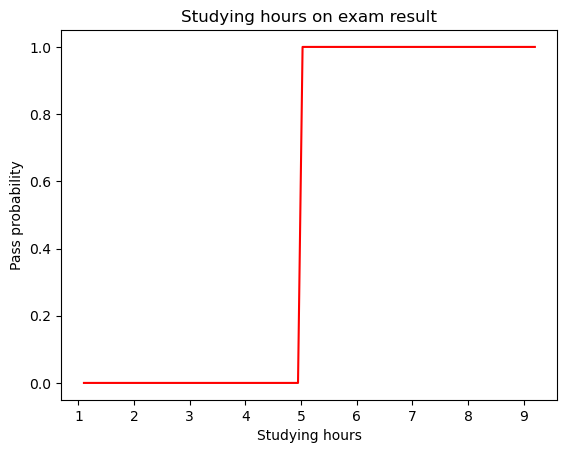

In [37]:
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_plot = model.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', label='logistic regression')
plt.title('Studying hours on exam result')
plt.xlabel('Studying hours')
plt.ylabel('Pass probability')
plt.show()